# 08. ViT-B/16 with Weighted Loss and Staged Fine-Tuning

**Objective**  
The objective of this experiment is to test whether the gains in Notebook 02 came mainly from **staged fine-tuning** rather than focal loss itself.  
This notebook keeps the same ViT-B/16 backbone and augmentation pipeline, but now uses the original weighted BCE objective together with the staged optimization schedule:

- **Weighted BCEWithLogitsLoss** to preserve the recall-oriented objective from `01.vit_b16_weighted`  
- **Staged fine-tuning** to stabilize optimization by warming up the classification head first, then unfreezing the full backbone with a smaller learning rate  

**Model Architecture**

| Stage | Layers |
| --- | --- |
| Input | RGB dermoscopic image |
| Patch embedding | `16 × 16` image patches |
| Backbone | Pretrained `ViT-B/16` |
| Classification head | Final linear layer with `1` output |
| Output | Single logit for melanoma probability |

### Hypothesis

Compared with `01.vit_b16_weighted`, staged fine-tuning with weighted BCE should improve optimization stability and overall generalization while recovering some of the melanoma recall that was lost in Notebook 02.

### Summary of This Notebook

- Uses the same **pretrained ViT-B/16 model** for binary classification  
- Keeps the existing **augmented training pipeline** from the shared data transforms  
- Keeps **weighted BCEWithLogitsLoss(pos_weight=...)** from the baseline  
- Uses a **2-phase training schedule**: head warm-up first, then full fine-tuning with discriminative learning rates


### 1. Setup and Imports

This section loads the project modules, trainer utilities, and shared evaluation helpers, then selects the available compute device (`CUDA`, `MPS`, or `CPU`).  
It also imports the weighted-loss utilities needed to recreate the ViT baseline objective while changing only the fine-tuning schedule.


In [1]:
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd()] + list(Path.cwd().parents) if (p / 'src').exists())
sys.path.insert(0, str(ROOT))

import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim

from src.data.dataloader import get_dataloaders
from src.data.transform import get_augmented_train_transforms
from src.models.vit import ViTBinaryClassifier
from src.training.trainer import train_one_epoch, validate_one_epoch
from src.utils import plot_training_curves, find_best_threshold, evaluate_model

import random
import numpy as np

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")


Using device: cuda


### 2. Data Split and Weighted-Loss Configuration

The dataset is loaded using the predefined train, validation, and test CSV splits.  
This notebook keeps the same augmentation pipeline already used in `01.vit_b16_weighted`, but changes the optimization schedule while preserving the original weighted-loss objective:

- `ViTBinaryClassifier(pretrained=True, freeze_backbone=True)` for a stable head warm-up phase
- `BCEWithLogitsLoss(pos_weight=...)` to penalize missed melanoma more strongly
- `Adam` optimizer with **two phases**:
  - warm-up: train only the head
  - fine-tuning: unfreeze the full model with lower LR on the backbone and higher LR on the head
- Batch size `32` and image size `224 × 224` to match the ViT input format


In [2]:
train_loader, val_loader, test_loader = get_dataloaders(
    train_csv=str(ROOT / "data_new/splits/train.csv"),
    val_csv=str(ROOT / "data_new/splits/val.csv"),
    test_csv=str(ROOT / "data_new/splits/test.csv"),
    image_dir=str(ROOT / "data_new/images/train"),
    test_image_dir=str(ROOT / "data_new/images/test"),
    batch_size=32,
    image_size=224,
    num_workers=0,
    transform_train=get_augmented_train_transforms(image_size=224),
)

train_df = pd.read_csv(ROOT / "data_new/splits/train.csv")

num_melanoma = (train_df["label"] == 1).sum()
num_nevus = (train_df["label"] == 0).sum()
pos_weight_value = num_nevus / num_melanoma
pos_weight = torch.tensor([pos_weight_value], dtype=torch.float32, device=device)

warmup_epochs = 2
finetune_epochs = 8
num_epochs = warmup_epochs + finetune_epochs

warmup_lr = 1e-3
backbone_lr = 1e-5
head_lr = 5e-5

model = ViTBinaryClassifier(pretrained=True, freeze_backbone=True).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = optim.Adam(model.model.heads.head.parameters(), lr=warmup_lr)

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())

print(f"Training samples: {len(train_df)}")
print(f"Melanoma: {num_melanoma}")
print(f"Nevus: {num_nevus}")
print(f"pos_weight: {pos_weight_value:.4f}")
print(f"Warm-up epochs: {warmup_epochs}")
print(f"Fine-tune epochs: {finetune_epochs}")
print(f"Trainable params at start: {trainable_params:,} / {total_params:,}")
print("Augmentation check: using get_augmented_train_transforms(image_size=224)")


Training samples: 7991
Melanoma: 877
Nevus: 7114
pos_weight: 8.1117
Warm-up epochs: 2
Fine-tune epochs: 8
Trainable params at start: 769 / 85,799,425
Augmentation check: using get_augmented_train_transforms(image_size=224)


### 3. Train the ViT-B/16 Model with Staged Fine-Tuning

Training is split into two phases:

- **Warm-up phase**: only the classification head is trainable, so the new head can adapt to the dataset without disturbing pretrained backbone features too early
- **Fine-tuning phase**: the full ViT backbone is unfrozen, but the optimizer uses a smaller learning rate for backbone parameters and a larger one for the head

The checkpoint with the highest validation AUC is saved for later threshold tuning and test evaluation.


In [3]:
best_val_auc = 0.0
train_history, val_history = [], []
unfrozen = False

for epoch in range(num_epochs):
    if epoch == warmup_epochs and not unfrozen:
        for param in model.model.parameters():
            param.requires_grad = True

        backbone_params = [
            param
            for name, param in model.model.named_parameters()
            if not name.startswith('heads.head')
        ]
        head_params = list(model.model.heads.head.parameters())

        optimizer = optim.Adam(
            [
                {"params": backbone_params, "lr": backbone_lr},
                {"params": head_params, "lr": head_lr},
            ]
        )
        unfrozen = True
        print("Unfroze full backbone and switched to discriminative learning rates.")

    phase = "Warm-up" if epoch < warmup_epochs else "Fine-tune"

    train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_metrics = validate_one_epoch(model, val_loader, criterion, device)

    train_history.append(train_metrics)
    val_history.append(val_metrics)

    print(f"Epoch [{epoch+1}/{num_epochs}] | Phase: {phase}")
    print(f"  Train | Loss: {train_metrics['loss']:.4f}, Bal Acc: {train_metrics['balanced_accuracy']:.4f}, "
          f"Recall: {train_metrics['recall']:.4f}, F2: {train_metrics['f2']:.4f}, AUC: {train_metrics['auc']:.4f}")
    print(f"  Val   | Loss: {val_metrics['loss']:.4f}, Bal Acc: {val_metrics['balanced_accuracy']:.4f}, "
          f"Recall: {val_metrics['recall']:.4f}, F2: {val_metrics['f2']:.4f}, AUC: {val_metrics['auc']:.4f}")

    if val_metrics['auc'] > best_val_auc:
        best_val_auc = val_metrics['auc']
        torch.save(model.state_dict(), ROOT / 'models/vit_b16_weighted_staged_finetune.pth')
        print("  Saved best model.")


Epoch [1/10] | Phase: Warm-up
  Train | Loss: 0.9755, Bal Acc: 0.7098, Recall: 0.7149, F2: 0.5027, AUC: 0.7937
  Val   | Loss: 0.9046, Bal Acc: 0.7598, Recall: 0.8898, F2: 0.5782, AUC: 0.8396
  Saved best model.


Epoch [2/10] | Phase: Warm-up
  Train | Loss: 0.8606, Bal Acc: 0.7560, Recall: 0.7879, F2: 0.5607, AUC: 0.8440
  Val   | Loss: 0.8946, Bal Acc: 0.7543, Recall: 0.9068, F2: 0.5722, AUC: 0.8585
  Saved best model.
Unfroze full backbone and switched to discriminative learning rates.


Epoch [3/10] | Phase: Fine-tune
  Train | Loss: 0.8043, Bal Acc: 0.7695, Recall: 0.7879, F2: 0.5787, AUC: 0.8648
  Val   | Loss: 0.7526, Bal Acc: 0.7986, Recall: 0.9237, F2: 0.6243, AUC: 0.8959
  Saved best model.


Epoch [4/10] | Phase: Fine-tune
  Train | Loss: 0.6942, Bal Acc: 0.8168, Recall: 0.8506, F2: 0.6433, AUC: 0.9002
  Val   | Loss: 0.7047, Bal Acc: 0.8147, Recall: 0.8559, F2: 0.6512, AUC: 0.9039
  Saved best model.


Epoch [5/10] | Phase: Fine-tune
  Train | Loss: 0.6322, Bal Acc: 0.8403, Recall: 0.8677, F2: 0.6795, AUC: 0.9176
  Val   | Loss: 0.7216, Bal Acc: 0.8117, Recall: 0.9153, F2: 0.6421, AUC: 0.9101
  Saved best model.


Epoch [6/10] | Phase: Fine-tune
  Train | Loss: 0.5871, Bal Acc: 0.8527, Recall: 0.8780, F2: 0.6992, AUC: 0.9310
  Val   | Loss: 0.7345, Bal Acc: 0.7984, Recall: 0.9280, F2: 0.6239, AUC: 0.9125
  Saved best model.


Epoch [7/10] | Phase: Fine-tune
  Train | Loss: 0.5273, Bal Acc: 0.8684, Recall: 0.8951, F2: 0.7243, AUC: 0.9428
  Val   | Loss: 0.7633, Bal Acc: 0.8165, Recall: 0.8008, F2: 0.6595, AUC: 0.9008


Epoch [8/10] | Phase: Fine-tune
  Train | Loss: 0.4729, Bal Acc: 0.8886, Recall: 0.9145, F2: 0.7585, AUC: 0.9542
  Val   | Loss: 0.8062, Bal Acc: 0.8037, Recall: 0.8305, F2: 0.6368, AUC: 0.8983


Epoch [9/10] | Phase: Fine-tune
  Train | Loss: 0.4177, Bal Acc: 0.9008, Recall: 0.9213, F2: 0.7819, AUC: 0.9646
  Val   | Loss: 0.7974, Bal Acc: 0.8016, Recall: 0.7331, F2: 0.6412, AUC: 0.9067


Epoch [10/10] | Phase: Fine-tune
  Train | Loss: 0.3993, Bal Acc: 0.9115, Recall: 0.9396, F2: 0.7983, AUC: 0.9671
  Val   | Loss: 0.7688, Bal Acc: 0.8192, Recall: 0.8051, F2: 0.6634, AUC: 0.9105


### 4. Plot Training Curves

This notebook uses the shared evaluation utility to render the standard 2 × 2 dashboard: Loss, Balanced Accuracy, Recall, and F2.  
That keeps the staged fine-tuning experiment directly comparable with the weighted ViT baseline.


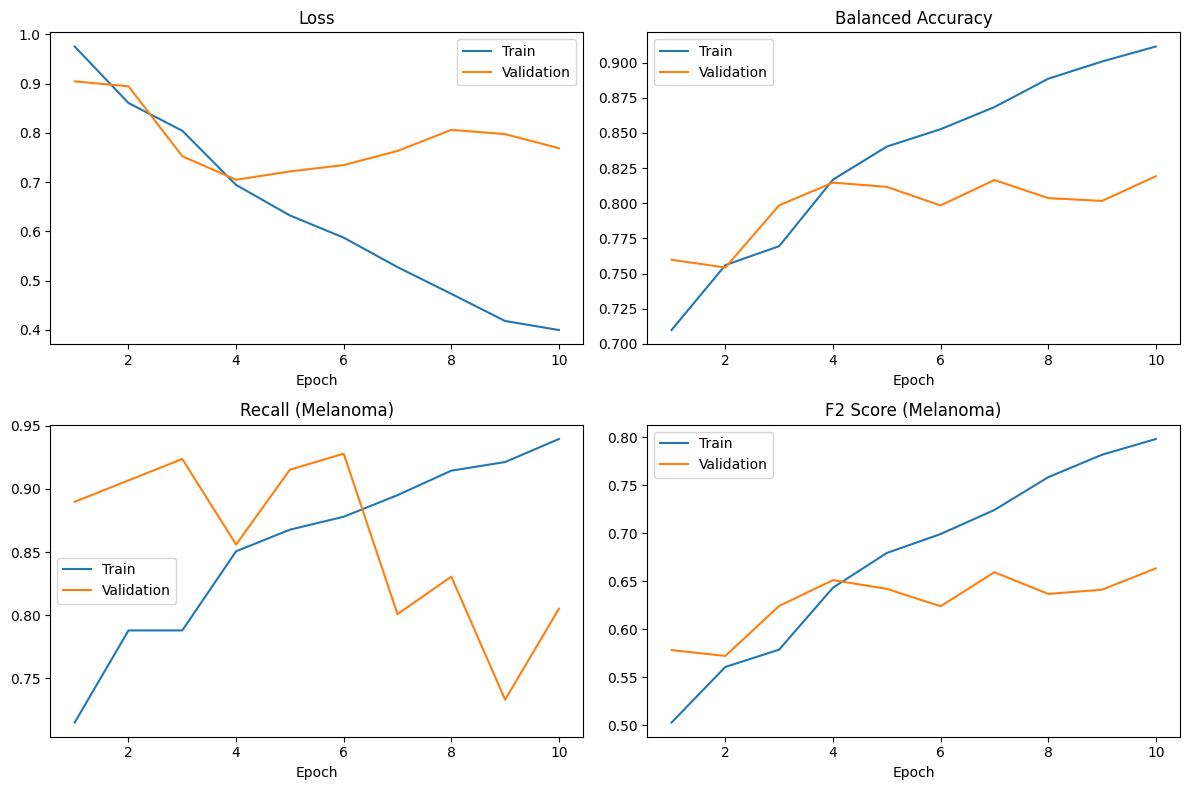

In [4]:
plot_training_curves(train_history, val_history)


### 5. Tune the Classification Threshold on the Validation Set

Even with weighted BCE and staged fine-tuning, the final operating point still needs to be selected separately.  
This step reloads the best saved checkpoint and finds the probability threshold that maximizes **F2 score** on the validation set.


In [5]:
model.load_state_dict(torch.load(ROOT / 'models/vit_b16_weighted_staged_finetune.pth', map_location=device))
best_threshold, best_f2 = find_best_threshold(model, val_loader, device)

print(f"Best validation threshold: {best_threshold:.2f}")
print(f"Best validation F2: {best_f2:.4f}")


Best threshold: 0.81 | Val F2: 0.6720
Best validation threshold: 0.81
Best validation F2: 0.6720


### 6. Evaluate on the Test Set

The best weighted staged ViT-B/16 checkpoint is evaluated on the held-out test set using the threshold selected on the validation set.  
The shared evaluation utility reports AUC-ROC, balanced accuracy, F2 score, a classification report, and visual diagnostics such as the confusion matrix and ROC curve.


Threshold:          0.81
AUC-ROC:            0.9066
Balanced Accuracy:  0.7943
F2 Score:           0.6256

              precision    recall  f1-score   support

Non-Melanoma     0.9610    0.8634    0.9096      1340
    Melanoma     0.4039    0.7251    0.5188       171

    accuracy                         0.8478      1511
   macro avg     0.6824    0.7943    0.7142      1511
weighted avg     0.8979    0.8478    0.8654      1511



c:\Users\Dylan Gay\Documents\SUTD\Deep Learning\50.039-Deep-Learning\dl_venv\Lib\site-packages\sklearn\utils\_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.7 and will be removed in 1.9. Use `name` instead.
  warnings.warn(


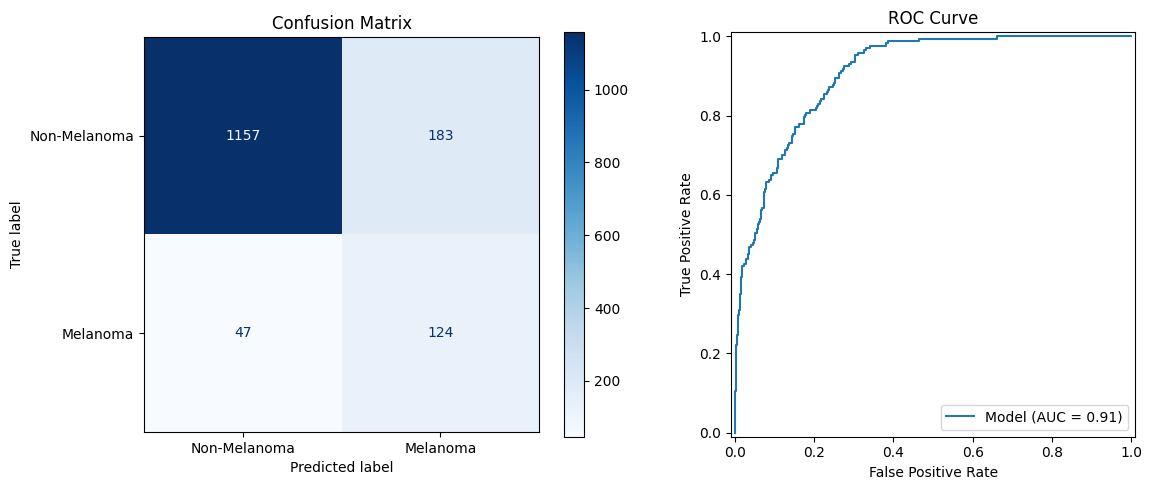

In [6]:
evaluate_model(model, test_loader, device, threshold=best_threshold)


### Results Summary (ViT-B/16 with Weighted Loss + Staged Fine-Tuning)

### 7. Baseline Interpretation

### Key Metrics
- **AUC-ROC:** ~0.907  
- **Best Threshold:** 0.81  
- **F2 Score:** ~0.626  
- **Balanced Accuracy:** ~0.794  

### Class-wise Performance
- **Melanoma Recall:** ~0.725  
- **Melanoma Precision:** ~0.404  
- **Non-melanoma Precision:** ~0.961  

### Key Observations
- Compared with `01.vit_b16_weighted`, test AUC-ROC improved from ~0.884 to ~0.907, balanced accuracy improved from ~0.783 to ~0.794, and F2 improved from ~0.601 to ~0.626.
- This shows staged fine-tuning is helpful even without focal loss: the optimization schedule alone improves overall ranking and downstream thresholded performance over the original weighted baseline.
- Compared with `02.vit_b16_focal_staged_finetune`, this notebook achieves slightly higher AUC (~0.907 vs ~0.904) and much higher melanoma precision (~0.404 vs ~0.346), but lower melanoma recall (~0.725 vs ~0.795) and slightly lower F2 (~0.626 vs ~0.631).
- The threshold moved much higher to 0.81, which makes the model more conservative. That improves false-positive control, but it is less aligned with a screening objective where recall is usually the top priority.

### Conclusion
- Staged fine-tuning is clearly helpful even without focal loss, because it improves AUC, balanced accuracy, F2, and melanoma precision over `01.vit_b16_weighted`.
- This is a stronger overall classifier than `01`, but it is not a better screening model than either `01` or `02` because melanoma recall is lower.
- Weighted BCE + staged fine-tuning gives the best melanoma precision among the three ViT notebooks so far, but focal loss + staged fine-tuning still gives a better recall-precision balance for screening because it retains more recall with nearly the same F2.
- Future improvements should focus on:
  - Recovering recall through threshold calibration or validation criteria better aligned with screening sensitivity
  - Testing milder focal-loss settings or alternative loss weighting to keep some of this precision gain without pushing recall too low
